# ERK/Akt Single-Cell Dataset: First Exploration

## Student Notebook

This notebook is a first pass over the dataset in this project folder. It is designed to help you:

- understand what each file contains,
- learn how each column should be interpreted,
- verify the experimental design encoded in the table,
- inspect the main variables linked to ERK and Akt signaling,
- connect rows to biological objects: cells, tracks, sites, and time points,
- produce a few safe first visualizations without loading the whole dataset into memory.

The main data file is large (more than 35 million rows), so the notebook uses `chunksize` and aggregated summaries.

## Biological Framing

The table contains time-resolved single-cell trajectories from MCF10A cells expressing:

- an ERK activity reporter: `ERKKTR_ratio`,
- a FoxO3A reporter: `FoxO3A_ratio`, often used as a readout related to Akt signaling,
- nuclear size and cell coordinates.

The metadata file maps imaging sites to genotypes. For a Systems Biology course, this is useful because students can connect **genetic perturbations in the PI3K/Akt axis** (`AKT1_E17K`, `PIK3CA_*`, `PTEN_del`) with **dynamic ERK/FoxO behavior at the single-cell level**.

In [15]:
from pathlib import Path
import math
import os
import tempfile

os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'mpl-config'))

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

ROOT = Path.cwd()
if not (ROOT / 'single-cell-tracks_exp1-6_noErbB2.csv.gz').exists():
    ROOT = ROOT.parent

DATA_PATH = ROOT / 'single-cell-tracks_exp1-6_noErbB2.csv.gz'
META_PATH = ROOT / '01-readme-experiment-description_2022-04-05.csv'

assert DATA_PATH.exists(), f'Missing data file: {DATA_PATH}'
assert META_PATH.exists(), f'Missing metadata file: {META_PATH}'

print('Data file:', DATA_PATH)
print('Metadata file:', META_PATH)
print('Compressed size [MB]:', round(DATA_PATH.stat().st_size / 1024**2, 1))

Data file: /Users/krzysiek/PROJECTS-MIMUW/UW-SysBiol-Project2/single-cell-tracks_exp1-6_noErbB2.csv.gz
Metadata file: /Users/krzysiek/PROJECTS-MIMUW/UW-SysBiol-Project2/01-readme-experiment-description_2022-04-05.csv
Compressed size [MB]: 625.1


In [16]:
meta = pd.read_csv(META_PATH, encoding='utf-8-sig')
meta = meta.rename(columns={'Site': 'Image_Metadata_Site'})
meta['Image_Metadata_Site'] = meta['Image_Metadata_Site'].astype(int)
meta = meta.sort_values('Image_Metadata_Site').reset_index(drop=True)

display(meta)
print('Rows in metadata:', len(meta))
print('\nMutation counts:')
display(meta['Mutation'].value_counts().rename_axis('Mutation').to_frame('n_sites'))

,Image_Metadata_Site,Cell_Line,Mutation,Biosensors,Conditions,Acquisition_frequency_min,Duration_h
0,1,MCF10A,WT,H2B-miRFP703_ErkKTR-mTurq.2_FoxO-mNeonGreen,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,5,24
1,2,MCF10A,WT,H2B-miRFP703_ErkKTR-mTurq.2_FoxO-mNeonGreen,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,5,24
2,3,MCF10A,WT,H2B-miRFP703_ErkKTR-mTurq.2_FoxO-mNeonGreen,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,5,24
3,4,MCF10A,WT,H2B-miRFP703_ErkKTR-mTurq.2_FoxO-mNeonGreen,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,5,24
4,5,MCF10A,AKT1_E17K,H2B-miRFP703_ErkKTR-mTurq.2_FoxO-mNeonGreen,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,5,24
5,6,MCF10A,AKT1_E17K,H2B-miRFP703_ErkKTR-mTurq.2_FoxO-mNeonGreen,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,5,24
6,7,MCF10A,AKT1_E17K,H2B-miRFP703_ErkKTR-mTurq.2_FoxO-mNeonGreen,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,5,24
7,8,MCF10A,AKT1_E17K,H2B-miRFP703_ErkKTR-mTurq.2_FoxO-mNeonGreen,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,5,24
8,9,MCF10A,PIK3CA_E545K,H2B-miRFP703_ErkKTR-mTurq.2_FoxO-mNeonGreen,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,5,24
9,10,MCF10A,PIK3CA_E545K,H2B-miRFP703_ErkKTR-mTurq.2_FoxO-mNeonGreen,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,5,24


Rows in metadata: 28

Mutation counts:


,n_sites
Mutation,
PTEN_del,8
WT,4
AKT1_E17K,4
PIK3CA_E545K,4
PIK3CA_H1047R,4
ErbB2,4


## Understanding the Metadata Table

Before looking at trajectories, it helps to understand the experiment-description table.
Here, each row corresponds to one imaging site (field of view), not to one cell.

This table provides the biological and experimental context needed to interpret the big trajectory table:

- `Image_Metadata_Site` is the join key linking metadata to trajectories,
- `Mutation` tells you which genotype was imaged at that site,
- `Biosensors` describes the reporters used to measure ERK/FoxO-related signaling,
- `Conditions` records the experimental setup,
- `Acquisition_frequency_min` and `Duration_h` describe the intended sampling schedule.

A useful question to keep in mind is: **which columns identify biological groups, and which describe measurement timing or conditions?**

In [17]:
metadata_guide = pd.DataFrame(
    [
        {
            'column': 'Image_Metadata_Site',
            'role': 'join key / site identifier',
            'meaning': 'Field-of-view identifier used to connect the metadata table to the trajectory table.',
            'why_it_matters': 'This is the main bridge between genotype-level context and cell-level measurements.',
        },
        {
            'column': 'Cell_Line',
            'role': 'biological context',
            'meaning': 'Cell background used in the experiment.',
            'why_it_matters': 'This helps you see what is held constant across sites.',
        },
        {
            'column': 'Mutation',
            'role': 'experimental grouping variable',
            'meaning': 'Genetic perturbation associated with the site.',
            'why_it_matters': 'This will define many comparisons across conditions.',
        },
        {
            'column': 'Biosensors',
            'role': 'measurement description',
            'meaning': 'Reporter constructs used to read out signaling state.',
            'why_it_matters': 'This explains why ERK- and FoxO-related columns exist in the trajectory table.',
        },
        {
            'column': 'Conditions',
            'role': 'experimental condition',
            'meaning': 'Culture and acquisition conditions for the plate.',
            'why_it_matters': 'This is useful context when comparing perturbations and reproducibility.',
        },
        {
            'column': 'Acquisition_frequency_min',
            'role': 'time sampling metadata',
            'meaning': 'Intended interval between successive frames, in minutes.',
            'why_it_matters': 'This lets you convert frame numbers into biological time.',
        },
        {
            'column': 'Duration_h',
            'role': 'planned experiment duration',
            'meaning': 'Nominal total duration of the acquisition, in hours.',
            'why_it_matters': 'This is worth comparing with the actual number of frames in the exported data.',
        },
    ]
)

display(metadata_guide)
print('Unique values per metadata column:')
display(meta.nunique().rename_axis('column').to_frame('n_unique_values'))

,column,role,meaning,why_it_matters
0,Image_Metadata_Site,join key / site identifier,Field-of-view identifier used to connect the m...,This is the main bridge between genotype-level...
1,Cell_Line,biological context,Cell background used in the experiment.,This helps you see what is held constant acros...
2,Mutation,experimental grouping variable,Genetic perturbation associated with the site.,This will define many comparisons across condi...
3,Biosensors,measurement description,Reporter constructs used to read out signaling...,This explains why ERK- and FoxO-related column...
4,Conditions,experimental condition,Culture and acquisition conditions for the plate.,This is useful context when comparing perturba...
5,Acquisition_frequency_min,time sampling metadata,"Intended interval between successive frames, i...",This lets you convert frame numbers into biolo...
6,Duration_h,planned experiment duration,"Nominal total duration of the acquisition, in ...",This is worth comparing with the actual number...


Unique values per metadata column:


,n_unique_values
column,
Image_Metadata_Site,28
Cell_Line,1
Mutation,6
Biosensors,1
Conditions,1
Acquisition_frequency_min,1
Duration_h,1


## Quick Check of the Big Table

We start with a tiny read to inspect schema and a few rows. This is enough to confirm the column names and get a first sense of the trajectory structure.

In [18]:
preview = pd.read_csv(DATA_PATH, nrows=5)
preview

,Exp_ID,Image_Metadata_Site,track_id,Image_Metadata_T,Nuclear_size,ERKKTR_ratio,FoxO3A_ratio,objNuclei_Location_Center_X,objNuclei_Location_Center_Y
0,1,1,1,0,303.000,0.704407,1.33383,932.211,875.248
1,1,1,1,1,333.000,0.848242,1.33791,932.150,874.174
2,1,1,1,2,314.000,1.059170,1.37627,932.376,873.787
3,1,1,1,3,322.000,1.188000,1.35754,932.168,873.453
4,1,1,1,4,313.999,1.205540,1.36695,931.146,872.885


In [19]:
schema = pd.read_csv(DATA_PATH, nrows=1000)
print(schema.dtypes)
print('\nMissing values in first 1000 rows:')
display(schema.isna().sum().to_frame('n_missing'))

Exp_ID                           int64
Image_Metadata_Site              int64
track_id                         int64
Image_Metadata_T                 int64
Nuclear_size                   float64
ERKKTR_ratio                   float64
FoxO3A_ratio                   float64
objNuclei_Location_Center_X    float64
objNuclei_Location_Center_Y    float64
dtype: object

Missing values in first 1000 rows:


,n_missing
Exp_ID,0
Image_Metadata_Site,0
track_id,0
Image_Metadata_T,0
Nuclear_size,0
ERKKTR_ratio,0
FoxO3A_ratio,0
objNuclei_Location_Center_X,0
objNuclei_Location_Center_Y,0


## Reading the Trajectory Table as Biology

The large CSV is the core data object. A very important conceptual step is to understand what **one row** means.

In this dataset, one row is best interpreted as:

> one tracked cell, at one time point, in one experiment, at one imaging site.

That means different columns play different roles:

- some columns identify the experimental context (`Exp_ID`, `Image_Metadata_Site`),
- some identify the cell trajectory (`track_id`),
- one gives time (`Image_Metadata_T`),
- some describe signaling or morphology (`ERKKTR_ratio`, `FoxO3A_ratio`, `Nuclear_size`),
- some describe spatial position within the microscope field (`objNuclei_Location_Center_X`, `objNuclei_Location_Center_Y`).

This distinction matters because later analyses will ask very different questions about identifiers, time, space, and signals.

In [20]:
trajectory_guide = pd.DataFrame(
    [
        {
            'column': 'Exp_ID',
            'role': 'experiment identifier',
            'meaning': 'Which experiment replicate/block the row comes from.',
            'how_to_think_about_it': 'Useful for separating repeated experiments from within-experiment cell variation.',
        },
        {
            'column': 'Image_Metadata_Site',
            'role': 'site identifier / join key',
            'meaning': 'Microscopy field of view within an experiment.',
            'how_to_think_about_it': 'Needed to merge trajectory rows with genotype metadata.',
        },
        {
            'column': 'track_id',
            'role': 'cell trajectory identifier',
            'meaning': 'Identifier for a tracked cell within an experiment-site block.',
            'how_to_think_about_it': 'A single track should generate many rows across time.',
        },
        {
            'column': 'Image_Metadata_T',
            'role': 'time index',
            'meaning': 'Frame number in the acquisition sequence.',
            'how_to_think_about_it': 'Convert to minutes or hours using acquisition frequency.',
        },
        {
            'column': 'Nuclear_size',
            'role': 'morphology readout',
            'meaning': 'Estimated nucleus size for the segmented object.',
            'how_to_think_about_it': 'Can reflect cell state, segmentation quality, or morphology changes.',
        },
        {
            'column': 'ERKKTR_ratio',
            'role': 'signaling readout',
            'meaning': 'ERK reporter-derived ratio for the cell at that frame.',
            'how_to_think_about_it': 'A dynamic variable likely to fluctuate over time within cells.',
        },
        {
            'column': 'FoxO3A_ratio',
            'role': 'signaling readout',
            'meaning': 'FoxO3A reporter-derived ratio related to Akt-pathway activity.',
            'how_to_think_about_it': 'Interpret jointly with ERK when studying pathway cross-talk.',
        },
        {
            'column': 'objNuclei_Location_Center_X',
            'role': 'spatial coordinate',
            'meaning': 'X-position of the nucleus center in the image.',
            'how_to_think_about_it': 'Useful for later spatial analyses, but positions are local to a field of view.',
        },
        {
            'column': 'objNuclei_Location_Center_Y',
            'role': 'spatial coordinate',
            'meaning': 'Y-position of the nucleus center in the image.',
            'how_to_think_about_it': 'Can help study neighborhoods, density, and collective structure within a site.',
        },
    ]
)

display(trajectory_guide)

sample_profile = schema.copy()
column_profile = (
    pd.DataFrame(
        {
            'dtype': sample_profile.dtypes.astype(str),
            'n_unique_in_sample': sample_profile.nunique(dropna=False),
            'missing_in_sample': sample_profile.isna().sum(),
            'sample_min': sample_profile.min(numeric_only=False),
            'sample_max': sample_profile.max(numeric_only=False),
        }
    )
    .rename_axis('column')
    .reset_index()
)

display(column_profile)

,column,role,meaning,how_to_think_about_it
0,Exp_ID,experiment identifier,Which experiment replicate/block the row comes...,Useful for separating repeated experiments fro...
1,Image_Metadata_Site,site identifier / join key,Microscopy field of view within an experiment.,Needed to merge trajectory rows with genotype ...
2,track_id,cell trajectory identifier,Identifier for a tracked cell within an experi...,A single track should generate many rows acros...
3,Image_Metadata_T,time index,Frame number in the acquisition sequence.,Convert to minutes or hours using acquisition ...
4,Nuclear_size,morphology readout,Estimated nucleus size for the segmented object.,"Can reflect cell state, segmentation quality, ..."
5,ERKKTR_ratio,signaling readout,ERK reporter-derived ratio for the cell at tha...,A dynamic variable likely to fluctuate over ti...
6,FoxO3A_ratio,signaling readout,FoxO3A reporter-derived ratio related to Akt-p...,Interpret jointly with ERK when studying pathw...
7,objNuclei_Location_Center_X,spatial coordinate,X-position of the nucleus center in the image.,"Useful for later spatial analyses, but positio..."
8,objNuclei_Location_Center_Y,spatial coordinate,Y-position of the nucleus center in the image.,"Can help study neighborhoods, density, and col..."


,column,dtype,n_unique_in_sample,missing_in_sample,sample_min,sample_max
0,Exp_ID,int64,1,0,1.000000,1.00000
1,Image_Metadata_Site,int64,1,0,1.000000,1.00000
2,track_id,int64,4,0,1.000000,4.00000
3,Image_Metadata_T,int64,258,0,0.000000,257.00000
4,Nuclear_size,float64,360,0,192.000000,388.00000
5,ERKKTR_ratio,float64,997,0,0.545956,1.40275
6,FoxO3A_ratio,float64,984,0,1.010910,1.49875
7,objNuclei_Location_Center_X,float64,995,0,121.862000,936.11900
8,objNuclei_Location_Center_Y,float64,984,0,335.858000,875.24800


In [21]:
track_sample = pd.read_csv(DATA_PATH, nrows=50_000)
track_lengths = (
    track_sample
    .groupby(['Exp_ID', 'Image_Metadata_Site', 'track_id'])
    .size()
    .sort_values(ascending=False)
)

sample_key = track_lengths.index[0]
exp_id, site_id, track_id = sample_key
one_track = (
    track_sample[
        (track_sample['Exp_ID'] == exp_id)
        & (track_sample['Image_Metadata_Site'] == site_id)
        & (track_sample['track_id'] == track_id)
    ]
    .sort_values('Image_Metadata_T')
    .copy()
)

frame_to_min = float(meta['Acquisition_frequency_min'].iloc[0])
one_track['time_min'] = one_track['Image_Metadata_T'] * frame_to_min
one_track['delta_x'] = one_track['objNuclei_Location_Center_X'].diff()
one_track['delta_y'] = one_track['objNuclei_Location_Center_Y'].diff()

print(f'Sample trajectory: Exp_ID={exp_id}, Site={site_id}, track_id={track_id}')
print('Rows shown from one tracked cell across time:')
display(one_track.head(12))

Sample trajectory: Exp_ID=1, Site=1, track_id=1
Rows shown from one tracked cell across time:


,Exp_ID,Image_Metadata_Site,track_id,Image_Metadata_T,Nuclear_size,ERKKTR_ratio,FoxO3A_ratio,objNuclei_Location_Center_X,objNuclei_Location_Center_Y,time_min,delta_x,delta_y
0,1,1,1,0,303.000,0.704407,1.33383,932.211,875.248,0.0,NaN,NaN
1,1,1,1,1,333.000,0.848242,1.33791,932.150,874.174,5.0,-0.061,-1.074
2,1,1,1,2,314.000,1.059170,1.37627,932.376,873.787,10.0,0.226,-0.387
3,1,1,1,3,322.000,1.188000,1.35754,932.168,873.453,15.0,-0.208,-0.334
4,1,1,1,4,313.999,1.205540,1.36695,931.146,872.885,20.0,-1.022,-0.568
5,1,1,1,5,306.000,1.208040,1.37352,931.513,873.072,25.0,0.367,0.187
6,1,1,1,6,327.000,1.165190,1.39633,931.080,872.260,30.0,-0.433,-0.812
7,1,1,1,7,305.000,1.094710,1.40610,930.784,872.144,35.0,-0.296,-0.116
8,1,1,1,8,302.999,1.001350,1.39646,930.594,871.914,40.0,-0.190,-0.230
9,1,1,1,9,331.000,0.931540,1.34251,930.918,872.079,45.0,0.324,0.165


Two useful interpretation lessons from the table above:

1. A single `track_id` produces many rows, because one cell is measured repeatedly over time.
2. Spatial coordinates can change from frame to frame, so they describe where the cell is in the field of view, not a fixed property of the mutation.

This means the same dataset already contains at least four layers of structure:

- **experimental structure**: experiment and mutation,
- **site structure**: field of view,
- **single-cell structure**: track identity,
- **dynamic structure**: repeated measurements over time.

## Exploratory Questions to Ask Early

Before moving to larger summaries, it helps to ask simple but powerful questions:

- Which columns identify groups, and which are measured variables?
- Which variables are expected to stay constant for a site, and which should vary across time within a track?
- Which columns are safe to average across cells, and which would lose meaning if averaged?
- Which variables describe signaling state, and which describe geometry or experimental design?
- Which comparisons make biological sense: across mutations, across sites, across tracks, or across time?

These questions help prevent a very common mistake in data science: using a column statistically before understanding what biological object it refers to.

## Chunked Summary Across the Full Dataset

This pass reads the whole compressed CSV, but only keeps compact summaries in memory.

Questions to answer:

- which experiment-site combinations are present in the exported file?
- how many rows and tracks are there per experiment-site block?
- how long are the time series in the actual export?
- what are the overall mean and standard deviation of ERK/FoxO/nuclear size per block?
- does the exported file really exclude the `ErbB2` sites from the metadata?

A key structural point is that the meaningful unit in this table is the pair `(Exp_ID, Image_Metadata_Site)`. The same site numbers are reused across experiments 1-6, while the mutation mapping comes from the site number.

In [22]:
SIGNAL_COLS = ['Nuclear_size', 'ERKKTR_ratio', 'FoxO3A_ratio']
USECOLS = ['Exp_ID', 'Image_Metadata_Site', 'track_id', 'Image_Metadata_T', *SIGNAL_COLS]
CHUNKSIZE = 1_000_000

site_stats = {}

for chunk in pd.read_csv(DATA_PATH, usecols=USECOLS, chunksize=CHUNKSIZE):
    for (exp_id, site), grp in chunk.groupby(['Exp_ID', 'Image_Metadata_Site']):
        key = (int(exp_id), int(site))
        if key not in site_stats:
            site_stats[key] = {
                'rows': 0,
                'track_ids': set(),
                'min_t': math.inf,
                'max_t': -math.inf,
                'sum_Nuclear_size': 0.0,
                'sumsq_Nuclear_size': 0.0,
                'sum_ERKKTR_ratio': 0.0,
                'sumsq_ERKKTR_ratio': 0.0,
                'sum_FoxO3A_ratio': 0.0,
                'sumsq_FoxO3A_ratio': 0.0,
            }

        stats = site_stats[key]
        stats['rows'] += len(grp)
        stats['track_ids'].update(grp['track_id'].unique().tolist())
        stats['min_t'] = min(stats['min_t'], int(grp['Image_Metadata_T'].min()))
        stats['max_t'] = max(stats['max_t'], int(grp['Image_Metadata_T'].max()))

        for col in SIGNAL_COLS:
            values = grp[col].astype(float)
            stats[f'sum_{col}'] += values.sum()
            stats[f'sumsq_{col}'] += np.square(values).sum()

summary_rows = []
for (exp_id, site), stats in sorted(site_stats.items()):
    row = {
        'Exp_ID': exp_id,
        'Image_Metadata_Site': site,
        'n_rows': stats['rows'],
        'n_tracks': len(stats['track_ids']),
        'min_t': int(stats['min_t']),
        'max_t': int(stats['max_t']),
        'n_timepoints': int(stats['max_t'] - stats['min_t'] + 1),
    }
    for col in SIGNAL_COLS:
        mean = stats[f'sum_{col}'] / stats['rows']
        var = stats[f'sumsq_{col}'] / stats['rows'] - mean**2
        row[f'{col}_mean'] = mean
        row[f'{col}_std'] = max(var, 0.0) ** 0.5
    summary_rows.append(row)

exp_site_summary = pd.DataFrame(summary_rows)
exp_site_summary = exp_site_summary.merge(meta, on='Image_Metadata_Site', how='left')
exp_site_summary['duration_from_frames_h'] = exp_site_summary['n_timepoints'] * exp_site_summary['Acquisition_frequency_min'] / 60.0
exp_site_summary = exp_site_summary.sort_values(['Exp_ID', 'Image_Metadata_Site']).reset_index(drop=True)

site_summary = exp_site_summary.copy()
exp_site_summary.head()

,Exp_ID,Image_Metadata_Site,n_rows,n_tracks,min_t,max_t,n_timepoints,Nuclear_size_mean,Nuclear_size_std,ERKKTR_ratio_mean,ERKKTR_ratio_std,FoxO3A_ratio_mean,FoxO3A_ratio_std,Cell_Line,Mutation,Biosensors,Conditions,Acquisition_frequency_min,Duration_h,duration_from_frames_h
0,1,1,356632,1798,0,257,258,326.585633,88.914529,0.847457,0.248491,1.306125,0.164385,MCF10A,WT,H2B-miRFP703_ErkKTR-mTurq.2_FoxO-mNeonGreen,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,5,24,21.5
1,1,2,341603,1594,0,257,258,334.722986,88.663755,0.834566,0.222950,1.313206,0.160418,MCF10A,WT,H2B-miRFP703_ErkKTR-mTurq.2_FoxO-mNeonGreen,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,5,24,21.5
2,1,3,356470,1685,0,257,258,334.287805,90.435314,0.839758,0.216288,1.300461,0.164313,MCF10A,WT,H2B-miRFP703_ErkKTR-mTurq.2_FoxO-mNeonGreen,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,5,24,21.5
3,1,4,378022,1896,0,257,258,321.497580,85.615457,0.846971,0.217157,1.281527,0.177145,MCF10A,WT,H2B-miRFP703_ErkKTR-mTurq.2_FoxO-mNeonGreen,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,5,24,21.5
4,1,5,448311,2009,0,257,258,274.821068,66.227356,0.835626,0.130636,1.369297,0.203160,MCF10A,AKT1_E17K,H2B-miRFP703_ErkKTR-mTurq.2_FoxO-mNeonGreen,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,5,24,21.5


In [23]:
present_site_ids = sorted(exp_site_summary['Image_Metadata_Site'].unique().tolist())
present_exp_ids = sorted(exp_site_summary['Exp_ID'].unique().tolist())
missing_site_ids = sorted(set(meta['Image_Metadata_Site']) - set(present_site_ids))

print('Unique Exp_ID values:', present_exp_ids)
print('Unique site IDs present in export:', present_site_ids)
print('Number of experiment-site blocks:', len(exp_site_summary))
print('Sites present in metadata but absent from export:', missing_site_ids)
print('Actual recording duration from frame count [h]:', exp_site_summary['duration_from_frames_h'].iloc[0])
print('Metadata duration [h]:', float(meta['Duration_h'].iloc[0]))

display(exp_site_summary[['Exp_ID', 'Image_Metadata_Site', 'Mutation', 'n_rows', 'n_tracks', 'n_timepoints', 'duration_from_frames_h']].head(20))

Unique Exp_ID values: [1, 2, 3, 4, 5, 6]
Unique site IDs present in export: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Number of experiment-site blocks: 120
Sites present in metadata but absent from export: [25, 26, 27, 28]
Actual recording duration from frame count [h]: 21.5
Metadata duration [h]: 24.0


,Exp_ID,Image_Metadata_Site,Mutation,n_rows,n_tracks,n_timepoints,duration_from_frames_h
0,1,1,WT,356632,1798,258,21.5
1,1,2,WT,341603,1594,258,21.5
2,1,3,WT,356470,1685,258,21.5
3,1,4,WT,378022,1896,258,21.5
4,1,5,AKT1_E17K,448311,2009,258,21.5
5,1,6,AKT1_E17K,440567,1988,258,21.5
6,1,7,AKT1_E17K,382261,1757,258,21.5
7,1,8,AKT1_E17K,427664,2003,258,21.5
8,1,9,PIK3CA_E545K,326279,1932,258,21.5
9,1,10,PIK3CA_E545K,344904,1997,258,21.5


At this point we can check two key interpretation issues.

1. The export corresponds to `Exp_ID` values 1-6, with the same site numbering reused inside each experiment.
2. The file name `noErbB2` is consistent with the absence of site IDs 25-28, which are the `ErbB2` sites in the metadata.

It is also useful to notice that the metadata says `24 h`, but the exported trajectories span 258 frames. At 5 minutes per frame, that gives 21.5 hours of measured data, so it is worth verifying timing directly from the table rather than relying only on the experiment description.

In [24]:
mutation_summary = (
    exp_site_summary
    .groupby('Mutation')
    .agg(
        n_exp_site_blocks=('Image_Metadata_Site', 'size'),
        n_unique_site_ids=('Image_Metadata_Site', 'nunique'),
        total_rows=('n_rows', 'sum'),
        total_tracks=('n_tracks', 'sum'),
        mean_ERK=('ERKKTR_ratio_mean', 'mean'),
        mean_FoxO=('FoxO3A_ratio_mean', 'mean'),
        mean_nuclear_size=('Nuclear_size_mean', 'mean'),
    )
    .sort_values('total_tracks', ascending=False)
)
mutation_summary

,n_exp_site_blocks,n_unique_site_ids,total_rows,total_tracks,mean_ERK,mean_FoxO,mean_nuclear_size
Mutation,,,,,,,
PIK3CA_E545K,24,4,8443205,53282,0.924411,1.249472,338.656762
AKT1_E17K,21,4,8797999,40174,0.836382,1.365192,290.893294
WT,24,4,7874257,38627,0.851648,1.283629,347.247903
PIK3CA_H1047R,24,4,4661580,35589,1.057998,1.285080,513.294571
PTEN_del,27,8,5764607,29237,0.924209,1.270296,387.589812


/var/folders/24/9ggqzqs92qdc3b845dk3z2b00000gn/T/ipykernel_23128/741593409.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=exp_site_summary, x='Mutation', y='n_tracks', estimator=sum, errorbar=None, ax=axes[0], palette='viridis')
/var/folders/24/9ggqzqs92qdc3b845dk3z2b00000gn/T/ipykernel_23128/741593409.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=exp_site_summary, x='Mutation', y='ERKKTR_ratio_mean', errorbar='sd', ax=axes[1], palette='mako')
/var/folders/24/9ggqzqs92qdc3b845dk3z2b00000gn/T/ipykernel_23128/741593409.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `

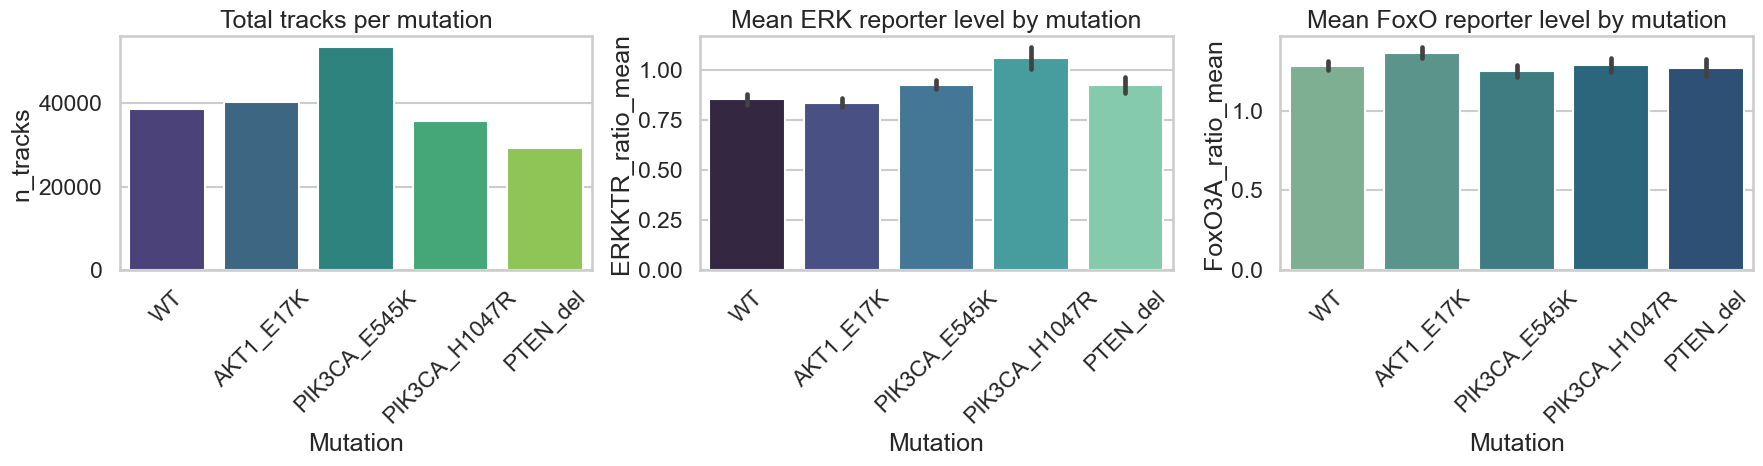

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=exp_site_summary, x='Mutation', y='n_tracks', estimator=sum, errorbar=None, ax=axes[0], palette='viridis')
axes[0].set_title('Total tracks per mutation')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=exp_site_summary, x='Mutation', y='ERKKTR_ratio_mean', errorbar='sd', ax=axes[1], palette='mako')
axes[1].set_title('Mean ERK reporter level by mutation')
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(data=exp_site_summary, x='Mutation', y='FoxO3A_ratio_mean', errorbar='sd', ax=axes[2], palette='crest')
axes[2].set_title('Mean FoxO reporter level by mutation')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()

## Mean Signaling Dynamics Over Time

A more informative systems-level view is to compare time courses by mutation. The code below performs a second chunked pass and aggregates the mean ERK and FoxO reporter values at each frame for each mutation.

This is still a population average, so it will smooth out single-cell pulses. That is an important limitation to keep in mind: **population means can hide heterogeneous pulsatile behavior**.

In [26]:
site_to_mutation = meta.set_index('Image_Metadata_Site')['Mutation'].to_dict()

time_summaries = []
for chunk in pd.read_csv(DATA_PATH, usecols=['Image_Metadata_Site', 'Image_Metadata_T', 'ERKKTR_ratio', 'FoxO3A_ratio'], chunksize=CHUNKSIZE):
    chunk['Mutation'] = chunk['Image_Metadata_Site'].map(site_to_mutation)
    grouped = (
        chunk
        .groupby(['Mutation', 'Image_Metadata_T'])
        .agg(
            ERK_sum=('ERKKTR_ratio', 'sum'),
            ERK_count=('ERKKTR_ratio', 'count'),
            FoxO_sum=('FoxO3A_ratio', 'sum'),
            FoxO_count=('FoxO3A_ratio', 'count'),
        )
    )
    time_summaries.append(grouped)

combined = pd.concat(time_summaries)
combined = combined.groupby(level=[0, 1]).sum().reset_index()
combined['ERKKTR_ratio_mean'] = combined['ERK_sum'] / combined['ERK_count']
combined['FoxO3A_ratio_mean'] = combined['FoxO_sum'] / combined['FoxO_count']

frame_to_minutes = float(meta['Acquisition_frequency_min'].iloc[0])
combined['time_h'] = combined['Image_Metadata_T'] * frame_to_minutes / 60.0
combined.head()

,Mutation,Image_Metadata_T,ERK_sum,ERK_count,FoxO_sum,FoxO_count,ERKKTR_ratio_mean,FoxO3A_ratio_mean,time_h
0,AKT1_E17K,0,28952.261607,34327,46520.477197,34327,0.843425,1.355215,0.000000
1,AKT1_E17K,1,28933.626340,34336,46527.298710,34336,0.842662,1.355059,0.083333
2,AKT1_E17K,2,28887.522379,34325,46500.785591,34325,0.841588,1.354721,0.166667
3,AKT1_E17K,3,28859.258035,34325,46481.175620,34325,0.840765,1.354149,0.250000
4,AKT1_E17K,4,28830.009230,34315,46485.059507,34315,0.840158,1.354657,0.333333


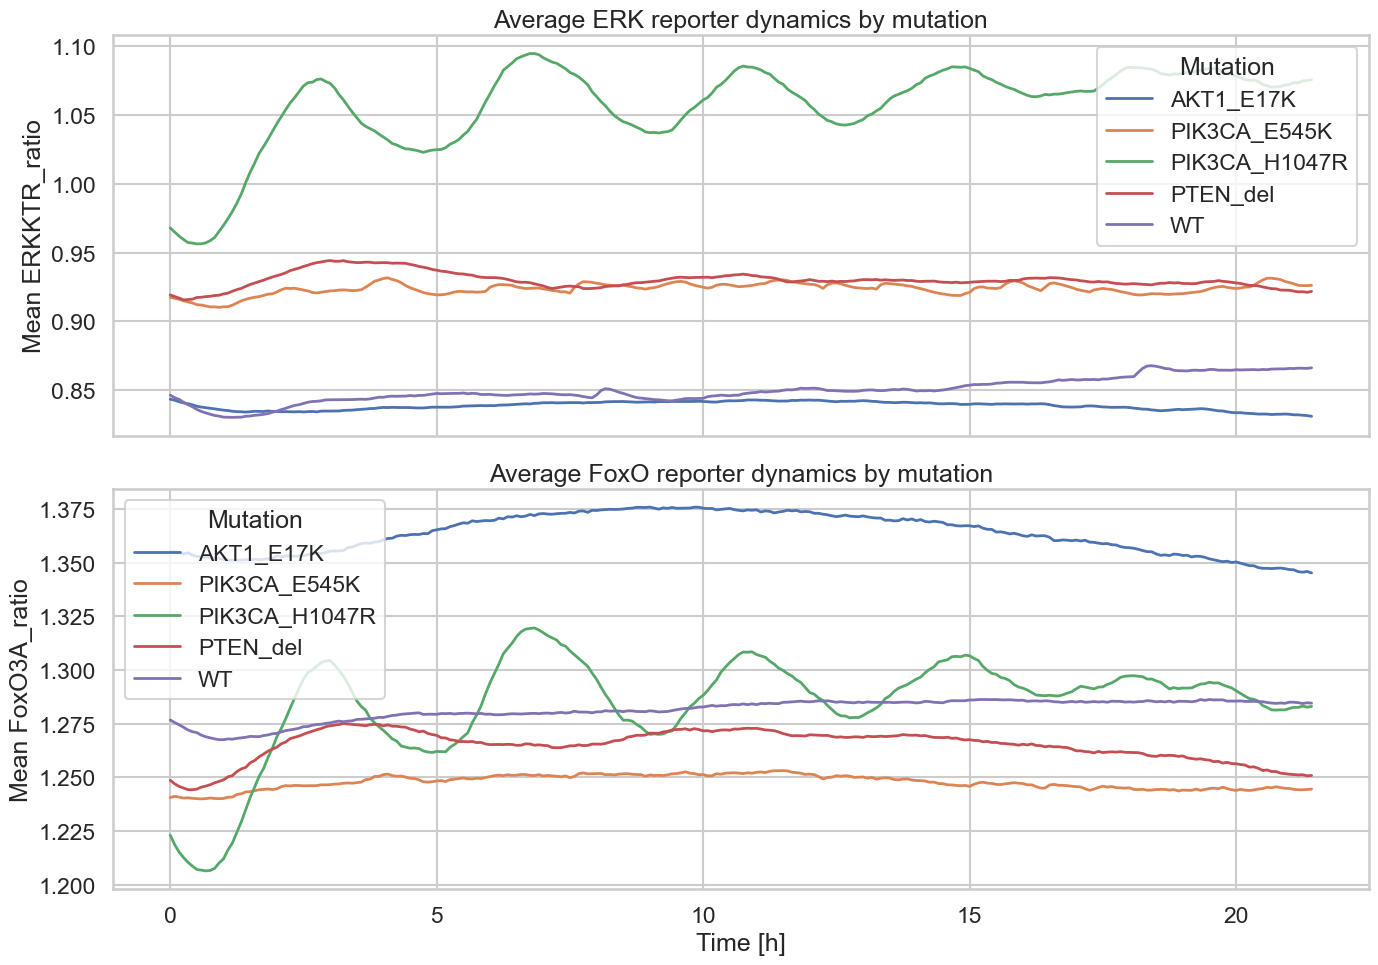

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

sns.lineplot(data=combined, x='time_h', y='ERKKTR_ratio_mean', hue='Mutation', ax=axes[0], linewidth=2)
axes[0].set_title('Average ERK reporter dynamics by mutation')
axes[0].set_ylabel('Mean ERKKTR_ratio')

sns.lineplot(data=combined, x='time_h', y='FoxO3A_ratio_mean', hue='Mutation', ax=axes[1], linewidth=2)
axes[1].set_title('Average FoxO reporter dynamics by mutation')
axes[1].set_ylabel('Mean FoxO3A_ratio')
axes[1].set_xlabel('Time [h]')

plt.tight_layout()

## Interpretation Notes

A first-pass understanding of the dataset should include these points:

1. `Image_Metadata_Site` is the practical link between the trajectory table and the experiment description.
2. The metadata contains 28 sites, but the exported trajectory file should contain only the non-`ErbB2` subset.
3. `ERKKTR_ratio` and `FoxO3A_ratio` are dynamic single-cell reporter readouts, so both mean levels and temporal structure matter.
4. `objNuclei_Location_Center_X` and `objNuclei_Location_Center_Y` are spatial coordinates inside an image, which makes them promising for later neighborhood and collective analyses.
5. Because measurements are repeated every 5 minutes for 24 hours, the dataset is suitable for studying signaling dynamics rather than only endpoint differences.
6. Averages are useful for orientation, but the biologically interesting behavior may live in cell-to-cell heterogeneity, pulsing, adaptation, spatial coordination, and cross-talk between ERK and Akt/FoxO.

## Where This Exploration Leads Next

After this notebook, the natural next steps are to study:

- temporal structure: pulses, trends, and adaptation over time,
- spatial structure: where cells are and how local neighborhoods differ,
- collective structure: whether nearby cells show coordinated behavior,
- track-level heterogeneity: how single cells differ even within the same mutation.

The goal of this first notebook is to build enough confidence with the dataset structure that those next analyses make biological and statistical sense.